# S&P 500 Options: Label Engineering

This notebook constructs labels for the S&P 500 Options case study using
**same-contract returns** built directly from the slim daily straddle panel
and the slim lifecycle-preserving raw straddle slice. Labels are short straddle
returns: sell a 30D ATM straddle at mid, buy back the **same contract** at mid
after h days. Positive return = profitable short vol position before costs.

**Learning Objectives**:
- Construct instrument-level labels from same-contract exit prices
- Implement delta-hedged returns using the held contract's delta path
- Generate walk-forward CV splits with a buffer that spans the ~30-day horizon
- Establish a VRP baseline IC that engineered features must beat

**Book Reference**: Chapter 7, Section 7.2 (Label Engineering)

**Prerequisites**: [`01_feasibility_analysis`](01_feasibility_analysis.ipynb)

**Primary label**: `ret_to_expiry` - the hold-to-expiry (HTM) short-straddle
return declared in `setup.yaml::labels.primary`. Every downstream model in this
case study trains on it. The horizon-based variants (`fwd_ret_{5,10}d`, their
delta-hedged and executable counterparts) are also built here to characterise
the pricing and hedging mechanics, but they are diagnostic, not modelled.

**Pricing Convention**: Mid-to-mid labels measure the economic signal.
Executable labels (sell at bid, close at ask) bake in the per-contract
bid-ask spread and reveal that the unconditional 10-day short straddle return
falls to **-9.6%** per trade, even though its mid-to-mid counterpart is +5.7%.
The exit-leg spread is what `ret_to_expiry` avoids: cash settlement at
expiration converts the option to intrinsic value with no market exit. Whether
ML selection plus the O'Donovan-Yu cost-mitigation cascade turns this into a
viable strategy is the subject of Chapter 18 (Section 18.8), not this notebook.

In [1]:
"""S&P 500 Options: Label Engineering - Same-Contract Short Straddle Returns."""

import json
import subprocess
import warnings
from datetime import UTC, datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from plotly.subplots import make_subplots
from scipy.stats import spearmanr

from case_studies.sp500_options._label_artifacts import ensure_label_artifacts
from case_studies.sp500_options._underlying_returns import reconcile_underlying_log_returns
from data import load_sp500_daily_bars, load_sp500_options_straddles
from utils.cv_splits import load_evaluation_config
from utils.paths import get_case_study_dir
from utils.style import COLORS  # registers the ml4t Plotly template on import

warnings.filterwarnings("ignore")

In [2]:
START_DATE = None  # None = use full dataset

In [3]:
CASE_DIR = get_case_study_dir("sp500_options")
LABELS_DIR = CASE_DIR / "labels"

STRATEGY_ID = "sp500_options"
INSTRUMENT_ID = "straddle_30d_atm"
FORWARD_HORIZONS = (5, 10)

## 1. Build and Load Same-Contract Returns

The slim reader dataset already includes the inputs needed for same-contract
label construction:

- `options_straddles_daily.parquet`
- `options_straddles_raw/year=*.parquet`

We build the persisted same-contract artifacts from those inputs here, then
read them for the downstream label calculations.

In [4]:
artifact_paths = ensure_label_artifacts()
contract_returns = pl.read_parquet(LABELS_DIR / "contract_returns.parquet")
print(f"Contract returns: {len(contract_returns):,} entries")
print(f"  Symbols: {contract_returns['symbol'].n_unique()}")
print(
    f"  Date range: {contract_returns['feature_date'].min()} to {contract_returns['feature_date'].max()}"
)

for h in FORWARD_HORIZONS:
    found = contract_returns[f"exit_found_{h}d"].sum()
    total = len(contract_returns)
    print(f"  Exit {h}d coverage: {found:,}/{total:,} ({found / total:.1%})")

Contract returns: 357,479 entries
  Symbols: 623
  Date range: 2017-01-03 to 2021-12-15
  Exit 5d coverage: 353,398/357,479 (98.9%)
  Exit 10d coverage: 341,134/357,479 (95.4%)


## 2. Unhedged Short Straddle Labels

The unhedged label uses the same-contract mid-to-mid return directly from
the same-contract artifact builder. No additional computation needed - just filter to valid
exits and format for downstream consumption.

$$r_{short} = \frac{(C_{entry} + P_{entry}) - (C_{exit} + P_{exit})}{C_{entry} + P_{entry}}$$

In [5]:
unhedged_labels = {}
for h in FORWARD_HORIZONS:
    label_col = f"fwd_ret_{h}d"
    lbl = (
        contract_returns.filter(pl.col(f"exit_found_{h}d"))
        .select(
            [
                pl.col("feature_date").alias("timestamp"),
                "symbol",
                pl.lit(INSTRUMENT_ID).alias("instrument_id"),
                label_col,
            ]
        )
        .drop_nulls(subset=[label_col])
    )
    unhedged_labels[label_col] = lbl
    stats = lbl[label_col]
    print(
        f"{label_col}: {len(lbl):,} rows, "
        f"mean={stats.mean():.4f}, std={stats.std():.4f}, median={stats.median():.4f}"
    )

fwd_ret_5d: 352,179 rows, mean=0.0071, std=0.2455, median=0.0645
fwd_ret_10d: 333,102 rows, mean=0.0572, std=0.3534, median=0.1491


## 2b. Executable Short Straddle Labels (Bid/Ask)

The mid-to-mid labels measure the economic signal. The **executable** labels
measure what a trader actually receives: sell at bid (entry), buy back at ask
(exit). The difference is the full bid-ask spread - the dominant cost for
single-stock options (~11% of premium round-trip).

$$r_{exec} = \frac{(C_{bid}^{entry} + P_{bid}^{entry}) - (C_{ask}^{exit} + P_{ask}^{exit})}{C_{bid}^{entry} + P_{bid}^{entry}}$$

In [6]:
exec_labels = {}
for h in FORWARD_HORIZONS:
    label_col = f"fwd_ret_exec_{h}d"
    valid = contract_returns.filter(pl.col(f"exit_found_{h}d"))
    lbl = (
        valid.with_columns(
            (pl.col("entry_call_bid") + pl.col("entry_put_bid")).alias("_entry_bid"),
            (pl.col(f"exit_call_{h}d_ask") + pl.col(f"exit_put_{h}d_ask")).alias("_exit_ask"),
        )
        .with_columns(
            ((pl.col("_entry_bid") - pl.col("_exit_ask")) / pl.col("_entry_bid")).alias(label_col)
        )
        .select(
            [
                pl.col("feature_date").alias("timestamp"),
                "symbol",
                pl.lit(INSTRUMENT_ID).alias("instrument_id"),
                label_col,
            ]
        )
        .drop_nulls(subset=[label_col])
    )
    exec_labels[label_col] = lbl
    stats = lbl[label_col]
    print(
        f"{label_col}: {len(lbl):,} rows, "
        f"mean={stats.mean():.4f}, std={stats.std():.4f}, "
        f"hit_rate={(stats > 0).mean():.1%}"
    )

fwd_ret_exec_5d: 352,179 rows, mean=-0.1486, std=0.3818, hit_rate=33.7%
fwd_ret_exec_10d: 333,102 rows, mean=-0.0963, std=0.4773, hit_rate=52.0%


The executable returns are substantially lower than mid-to-mid because the
full bid-ask spread is baked into entry and exit prices. The unconditional
executable return is negative - the average straddle is unprofitable after
spreads. The ML model's value is selecting the subset that remains profitable.

## 3. Delta-Hedged Short Straddle Labels

The delta-hedged variant isolates the volatility bet by removing directional
exposure. We use the **held contract's** delta path from the same-contract artifacts,
not the constant-maturity delta that jumps between contracts daily.

$$r_{dh} = r_{short} + \sum_{d=0}^{h-1} \Delta_d \cdot \frac{S_{d+1} - S_d}{P_{entry}}$$

where $\Delta_d$ is the held contract's net delta on holding day $d$,
and $S_d$ is the underlying price.

In [7]:
hedge_path = pl.read_parquet(LABELS_DIR / "hedge_path.parquet")
print(f"Hedge path: {len(hedge_path):,} rows")

Hedge path: 3,932,269 rows


In [8]:
# Compute daily underlying price changes along each holding path
hedge_sorted = hedge_path.sort(["symbol", "feature_date", "holding_day"])

# dS at each holding day: S[d] - S[d-1]
hedge_sorted = hedge_sorted.with_columns(
    (
        pl.col("underlying_price")
        - pl.col("underlying_price").shift(1).over(["symbol", "feature_date"])
    ).alias("dS")
)

# Hedge P&L each day: delta[d-1] * dS[d] (hedge established at previous close)
# For d=0, no dS (it's the entry day), so dS is null and excluded
hedge_sorted = hedge_sorted.with_columns(
    (pl.col("instr_delta").shift(1).over(["symbol", "feature_date"]) * pl.col("dS")).alias(
        "daily_hedge_pnl"
    )
)

In [9]:
# Accumulate daily hedge P&L over each horizon before joining the option return.
hedge_pnl_by_horizon = {}
for h in FORWARD_HORIZONS:
    hedge_pnl_by_horizon[h] = (
        hedge_sorted.filter((pl.col("holding_day") >= 1) & (pl.col("holding_day") <= h))
        .group_by(["feature_date", "symbol"])
        .agg(pl.col("daily_hedge_pnl").sum().alias("hedge_pnl"))
    )

Each horizon now combines the accumulated hedge P&L with its same-contract
option return and scales the hedge by the entry premium.

In [10]:
dh_labels = {}
for h in FORWARD_HORIZONS:
    label_col = f"fwd_ret_dh_{h}d"
    dh = (
        contract_returns.filter(pl.col(f"exit_found_{h}d"))
        .select(
            [
                "feature_date",
                "symbol",
                f"fwd_ret_{h}d",
                "entry_straddle_mid",
            ]
        )
        .join(hedge_pnl_by_horizon[h], on=["feature_date", "symbol"], how="left")
        .with_columns(
            (
                pl.col(f"fwd_ret_{h}d")
                + pl.col("hedge_pnl").fill_null(0) / pl.col("entry_straddle_mid")
            ).alias(label_col)
        )
    )

    lbl = dh.select(
        [
            pl.col("feature_date").alias("timestamp"),
            "symbol",
            pl.lit(INSTRUMENT_ID).alias("instrument_id"),
            label_col,
        ]
    ).drop_nulls(subset=[label_col])

    dh_labels[label_col] = lbl
    stats = lbl[label_col]
    print(
        f"{label_col}: {len(lbl):,} rows, "
        f"mean={stats.mean():.4f}, std={stats.std():.4f}, median={stats.median():.4f}"
    )

fwd_ret_dh_5d: 352,179 rows, mean=0.0008, std=0.1664, median=0.0284
fwd_ret_dh_10d: 333,102 rows, mean=0.0159, std=0.2273, median=0.0511


## 3c. Hold-to-Expiry Short Straddle Label

The horizon-based labels above close the position at $t + h$ days and pay the
full exit bid-ask spread. The **hold-to-expiry** (HTM) variant avoids the exit
spread entirely: cash settlement at expiration converts the option to
intrinsic value without any market transaction.

$$r_{\text{htm}} = \frac{P_{\text{entry}} - |S_T - K|}{P_{\text{entry}}}$$

where $S_T$ is the underlying close on the expiration date and $K$ is the
strike. Sign convention matches the other labels in this notebook: positive =
profitable short straddle. Verified on row (symbol=A, $K=50$, $S_T=51.63$,
$P_{\text{entry}}=3.60$): intrinsic $=1.63$, $r_{\text{htm}}=+54.7\%$.
Settlement uses the unadjusted historical close because the listed strike and
expiration spot are expressed in the same contemporaneous price basis.

Days-to-expiry is tight by design (25–35 calendar days, mean 30, std 2.6),
so no per-day normalization. We add DTE as a feature in `03_financial_features`.

This label grounds the cost-mitigation cascade introduced by O'Donovan & Yu
(2025): under conservative option transaction costs, HTM recovers 3 of 17
single-name option anomalies that fail at fixed holding periods.

In [11]:
underlying_close = load_sp500_daily_bars().select(
    [
        pl.col("symbol"),
        pl.col("timestamp").alias("expiration"),
        pl.col("close").alias("underlying_close_at_expiry"),
    ]
)

htm_label = (
    contract_returns.join(underlying_close, on=["symbol", "expiration"], how="inner")
    .with_columns(
        (pl.col("underlying_close_at_expiry") - pl.col("strike"))
        .abs()
        .alias("intrinsic_at_expiry"),
        ((pl.col("expiration") - pl.col("feature_date")).dt.total_days()).alias("dte_calendar"),
    )
    .with_columns(
        (
            (pl.col("entry_straddle_mid") - pl.col("intrinsic_at_expiry"))
            / pl.col("entry_straddle_mid")
        ).alias("ret_to_expiry")
    )
    .select(
        [
            pl.col("feature_date").alias("timestamp"),
            "symbol",
            pl.lit(INSTRUMENT_ID).alias("instrument_id"),
            "ret_to_expiry",
            pl.col("dte_calendar").cast(pl.Int32),
        ]
    )
    .drop_nulls(subset=["ret_to_expiry"])
)

htm_labels = {"ret_to_expiry": htm_label}

The summary confirms the available expiration coverage and the label's
return and horizon distribution.

In [12]:
_htm_dropped = len(contract_returns) - len(htm_label)
_ret_htm = htm_label["ret_to_expiry"]
print(
    f"ret_to_expiry: {len(htm_label):,} rows "
    f"(dropped {_htm_dropped:,} for expirations beyond underlying bars range)"
)
print(
    f"  mean={_ret_htm.mean():.4f}, std={_ret_htm.std():.4f}, "
    f"median={_ret_htm.median():.4f}, hit_rate={(_ret_htm > 0).mean():.1%}"
)
print(
    f"  dte_calendar: min={htm_label['dte_calendar'].min()}, "
    f"max={htm_label['dte_calendar'].max()}, "
    f"mean={htm_label['dte_calendar'].mean():.1f}"
)

ret_to_expiry: 354,473 rows (dropped 3,006 for expirations beyond underlying bars range)
  mean=-0.0242, std=1.1524, median=0.1881, hit_rate=59.4%
  dte_calendar: min=25, max=35, mean=30.1


## 4. Label Quality Diagnostics

Check distributions and the fraction of profitable trades.

In [13]:
_all_labels = {**unhedged_labels, **dh_labels, **exec_labels, **htm_labels}
# The modelled label is the hold-to-expiry return (setup.yaml::labels.primary);
# the diagnostics below characterise it, not the horizon-based variants.
_primary_name = "ret_to_expiry"
primary = _all_labels[_primary_name]
y_col = _primary_name

n_total = len(primary)
n_positive = primary.filter(pl.col(y_col) > 0).height
hit_rate = n_positive / n_total if n_total > 0 else 0

print(f"Primary label: {y_col}")
print(f"  Observations: {n_total:,}")
print(f"  Mean: {primary[y_col].mean():.4f}")
print(f"  Std: {primary[y_col].std():.4f}")
print(f"  Hit rate (positive): {hit_rate:.1%}")

Primary label: ret_to_expiry
  Observations: 354,473
  Mean: -0.0242
  Std: 1.1524
  Hit rate (positive): 59.4%


### Delta hedging narrows 10-day returns

Hold-to-expiry outcomes retain a pronounced loss tail, while delta hedging
concentrates the 10-day distribution by removing directional P&L.

In [14]:
fig = make_subplots(
    rows=1,
    cols=2,
    horizontal_spacing=0.13,
    subplot_titles=["Hold-to-Expiry (primary label)", "10-Day: hedged vs unhedged"],
)

htm_edges = np.arange(-3.0, 3.1, 0.1)
htm_counts, _ = np.histogram(primary[y_col].to_numpy(), bins=htm_edges)
htm_centers = (htm_edges[:-1] + htm_edges[1:]) / 2
fig.add_trace(
    go.Bar(
        x=htm_centers,
        y=htm_counts,
        width=0.1,
        marker_color=COLORS["blue"],
        opacity=0.85,
        name="ret_to_expiry",
    ),
    row=1,
    col=1,
)
_ = fig.add_vline(x=0, line_dash="dash", line_color=COLORS["negative"], row=1, col=1)

The 10-day panel overlays unhedged and held-contract delta-hedged outcomes
using identical bins and limits for a direct dispersion comparison.

In [15]:
uh_10d = unhedged_labels["fwd_ret_10d"]["fwd_ret_10d"]
dh_10d = dh_labels["fwd_ret_dh_10d"]["fwd_ret_dh_10d"]
ten_day_edges = np.arange(-1.5, 1.55, 0.05)
uh_counts, _ = np.histogram(uh_10d.to_numpy(), bins=ten_day_edges)
dh_counts, _ = np.histogram(dh_10d.to_numpy(), bins=ten_day_edges)
ten_day_centers = (ten_day_edges[:-1] + ten_day_edges[1:]) / 2
fig.add_trace(
    go.Bar(
        x=ten_day_centers,
        y=uh_counts,
        width=0.05,
        opacity=0.55,
        marker_color=COLORS["amber"],
        name="unhedged_10d",
    ),
    row=1,
    col=2,
)
fig.add_trace(
    go.Bar(
        x=ten_day_centers,
        y=dh_counts,
        width=0.05,
        opacity=0.55,
        marker_color=COLORS["blue"],
        name="dh_10d",
    ),
    row=1,
    col=2,
)
_ = fig.add_vline(x=0, line_dash="dash", line_color=COLORS["negative"], row=1, col=2)

Both panels focus on their central mass. The rendered note states the exact
displayed ranges so the omitted extreme tails remain explicit to readers.

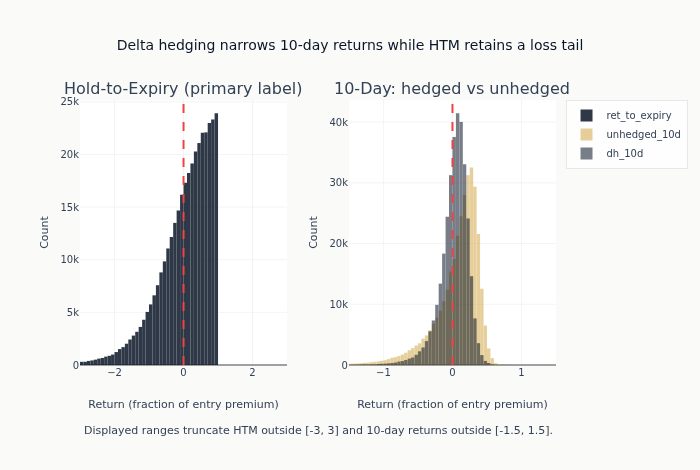

In [16]:
fig.update_layout(
    template="ml4t",
    height=470,
    barmode="overlay",
    title="Delta hedging narrows 10-day returns while HTM retains a loss tail",
    margin=dict(b=105),
)
fig.update_xaxes(title_text="Return (fraction of entry premium)", range=[-3, 3], row=1, col=1)
fig.update_xaxes(title_text="Return (fraction of entry premium)", range=[-1.5, 1.5], row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=2)
fig.add_annotation(
    text="Displayed ranges truncate HTM outside [-3, 3] and 10-day returns outside [-1.5, 1.5].",
    x=0.5,
    y=-0.28,
    xref="paper",
    yref="paper",
    showarrow=False,
    font=dict(color=COLORS["neutral"], size=11),
)
fig.show()

### Label Autocorrelation

The ~30-day hold-to-expiry horizon on daily data creates heavily overlapping
returns (consecutive entry dates share most of their holding window). This is
why `setup.yaml::labels.buffer` is 35D - the CV purge/embargo must span the
full label horizon to keep training and validation windows independent.

In [17]:
max_lag = 20
lag_acf = {}
for lag in range(1, max_lag + 1):
    acf_by_sym = []
    for sym in primary["symbol"].unique().to_list():
        sym_data = primary.filter(pl.col("symbol") == sym).sort("timestamp")
        y = sym_data[y_col].to_numpy()
        if len(y) > lag + 10:
            corr, _ = spearmanr(y[:-lag], y[lag:])
            if np.isfinite(corr):
                acf_by_sym.append(corr)
    if acf_by_sym:
        lag_acf[lag] = float(np.mean(acf_by_sym))

print("Label autocorrelation (avg across symbols):")
for lag, acf in lag_acf.items():
    marker = " ***" if lag <= 2 else ""
    print(f"  Lag {lag:2d}: {acf:+.3f}{marker}")

# Effective sample size
_acf_vals = [v for v in lag_acf.values() if v > 0]
_n_eff_denom = 1 + 2 * sum(_acf_vals)
n_eff = int(n_total / _n_eff_denom)
print(f"\nEffective sample size: N_eff = {n_eff:,} (N/{_n_eff_denom:.1f})")

Label autocorrelation (avg across symbols):
  Lag  1: +0.742 ***
  Lag  2: +0.592 ***
  Lag  3: +0.458
  Lag  4: +0.343
  Lag  5: +0.252
  Lag  6: +0.179
  Lag  7: +0.129
  Lag  8: +0.106
  Lag  9: +0.088
  Lag 10: +0.068
  Lag 11: +0.051
  Lag 12: +0.035
  Lag 13: +0.021
  Lag 14: +0.009
  Lag 15: -0.002
  Lag 16: -0.011
  Lag 17: -0.019
  Lag 18: -0.022
  Lag 19: -0.025
  Lag 20: -0.027

Effective sample size: N_eff = 49,590 (N/7.1)


### Baseline IC: VRP Proxy

The simplest VRP proxy ($IV_{atm} - RV_{21d}$) is the naive predictor of the
short-straddle return. Its rank IC against `ret_to_expiry` sets the floor that
engineered features must beat. **The floor is measured on the pre-2021
cross-validation window only** (`setup.yaml::evaluation.holdout_start`), so the
2021 holdout stays sealed against every quantity used to motivate feature work.
Realized volatility uses split-adjusted closes within stable `sec_id`
segments. Returns are null at identity changes, so an adjustment-factor reset
cannot masquerade as a market move. The hold-to-expiry label spans roughly 21
trading days, so inference uses a 20-lag Newey-West adjustment.

In [18]:
straddles = load_sp500_options_straddles()
underlying = load_sp500_daily_bars()
underlying_rv = (
    reconcile_underlying_log_returns(underlying)
    .sort(["symbol", "sec_id", "timestamp"])
    .with_columns(
        (
            pl.col("clean_log_return").rolling_std(21).over(["symbol", "sec_id"]) * np.sqrt(252)
        ).alias("rv_21d")
    )
    .sort(["symbol", "timestamp"])
)

vrp_baseline = straddles.select(["timestamp", "symbol", "iv_atm"]).join(
    underlying_rv.select(["timestamp", "symbol", "rv_21d"]).drop_nulls(),
    on=["timestamp", "symbol"],
    how="inner",
)
vrp_baseline = vrp_baseline.with_columns(
    (pl.col("iv_atm") - pl.col("rv_21d")).alias("vrp_proxy"),
)

_holdout_start = (
    pl.Series([load_evaluation_config("sp500_options")["holdout_start"]]).str.to_date().item()
)
vrp_eval = vrp_baseline.join(
    primary.select(["timestamp", "symbol", y_col]),
    on=["timestamp", "symbol"],
    how="inner",
).filter(pl.col("timestamp") < _holdout_start)  # seal the 2021 holdout

Daily rank IC is computed within each cross-section. Carrying the timestamp
with each estimate makes chronological ordering explicit before HAC inference.

In [19]:
ic_rows = []
for _key, group in vrp_eval.partition_by("timestamp", as_dict=True).items():
    valid = group.select(["vrp_proxy", y_col]).drop_nulls()
    if len(valid) >= 3:
        p = valid["vrp_proxy"].to_numpy()
        r = valid[y_col].to_numpy()
        if np.std(p) > 0 and np.std(r) > 0:
            corr, _ = spearmanr(p, r)
            if np.isfinite(corr):
                ic_rows.append({"timestamp": _key[0], "ic": float(corr)})

Horizon-aware HAC treats the overlapping daily IC observations as a time
series rather than independent draws.

In [20]:
if ic_rows:
    ic_series = pl.DataFrame(ic_rows).sort("timestamp")
    baseline_stats = compute_ic_hac_stats(ic_series, ic_col="ic", label_horizon=21)
    baseline_ic_mean = float(baseline_stats["mean_ic"])
    baseline_ic_std = float(ic_series["ic"].std())
    baseline_ic_tstat = float(baseline_stats["t_stat"])
    baseline_ic_pvalue = float(baseline_stats["p_value"])
    baseline_ic_lags = int(baseline_stats["effective_lags"])
    print(f"Baseline VRP proxy IC vs {y_col} (pre-2021 CV window):")
    print(f"  Mean IC: {baseline_ic_mean:.4f}")
    print(f"  IC std: {baseline_ic_std:.4f}")
    print(
        f"  HAC t-stat: {baseline_ic_tstat:.2f} "
        f"(p={baseline_ic_pvalue:.3f}, lags={baseline_ic_lags}, n_dates={len(ic_series)})"
    )
else:
    baseline_ic_mean = 0.0
    baseline_ic_tstat = 0.0
    baseline_ic_pvalue = 1.0
    baseline_ic_lags = 0
    print("Insufficient data for baseline IC computation")

Baseline VRP proxy IC vs ret_to_expiry (pre-2021 CV window):
  Mean IC: -0.0108
  IC std: 0.0962
  HAC t-stat: -1.23 (p=0.220, lags=20, n_dates=986)


## 5. Save Artifacts

In [21]:
LABELS_DIR.mkdir(parents=True, exist_ok=True)

# Save label files
for name, label_df in {**unhedged_labels, **dh_labels, **exec_labels, **htm_labels}.items():
    label_path = LABELS_DIR / f"{name}.parquet"
    label_df.write_parquet(label_path)
    print(f"Saved labels/{name}.parquet ({len(label_df):,} rows)")

# CV config from setup.yaml evaluation section
_eval_cfg = load_evaluation_config("sp500_options")
_cv_config_dict = {
    "n_splits": _eval_cfg["n_splits"],
    "train_size": str(_eval_cfg["train_size"]),
    "test_size": str(_eval_cfg["val_size"]),
    "holdout_start": _eval_cfg.get("holdout_start", ""),
    "holdout_end": _eval_cfg.get("holdout_end", ""),
    "calendar": _eval_cfg.get("calendar", "NYSE"),
}
_cv_path = CASE_DIR / "config" / "cv_config.json"
_cv_path.parent.mkdir(parents=True, exist_ok=True)
_cv_path.write_text(json.dumps(_cv_config_dict, indent=2))
print(f"Saved cv_config.json (n_splits={_cv_config_dict['n_splits']})")

Saved labels/fwd_ret_5d.parquet (352,179 rows)
Saved labels/fwd_ret_10d.parquet (333,102 rows)
Saved labels/fwd_ret_dh_5d.parquet (352,179 rows)
Saved labels/fwd_ret_dh_10d.parquet (333,102 rows)
Saved labels/fwd_ret_exec_5d.parquet (352,179 rows)
Saved labels/fwd_ret_exec_10d.parquet (333,102 rows)
Saved labels/ret_to_expiry.parquet (354,473 rows)
Saved cv_config.json (n_splits=2)


## 6. Results Collection

In [22]:
def _git_commit_hash():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"], text=True, timeout=5
        ).strip()
    except Exception:
        return "unknown"

Assemble the label, method, and diagnostic summaries separately so each
result group remains easy to inspect and reuse.

In [23]:
results_summary = {
    "n_observations": n_total,
    "n_symbols": primary["symbol"].n_unique(),
    "primary_label": _primary_name,
    "primary_mean": float(primary[y_col].mean()),
    "primary_std": float(primary[y_col].std()),
    "hit_rate": float(hit_rate),
    "label_variants": (
        list(unhedged_labels.keys())
        + list(dh_labels.keys())
        + list(exec_labels.keys())
        + list(htm_labels.keys())
    ),
}
results_techniques = {
    "instrument": "30D ATM matched-strike straddle",
    "sign_convention": "short straddle (positive = profitable)",
    "entry": "t+1 mid (selling) - same contract as feature date",
    "exit": "t+1+h mid (buying to close) - same contract looked up in raw chain",
    "pricing": "mid-to-mid (execution costs deferred to Ch18)",
    "hedging": "delta-hedged using held contract's delta path (not constant-maturity)",
}
results_diagnostics = {
    "horizons": list(FORWARD_HORIZONS),
    "n_cv_splits": _cv_config_dict["n_splits"],
    "straddle_coverage": f"{primary['symbol'].n_unique()} symbols",
}

The final record combines stable metadata with the current baseline estimate
and its overlap-aware uncertainty fields.

In [24]:
results = {
    "case_study_id": STRATEGY_ID,
    "chapter": 7,
    "stage": "labels",
    "timestamp": datetime.now(UTC).isoformat(),
    "git_commit": _git_commit_hash(),
    "notebook": f"case_studies/{STRATEGY_ID}/02_labels.py",
    "data_version": "v2_matched_strike_same_contract",
    "summary": results_summary,
    "techniques": results_techniques,
    "diagnostics": results_diagnostics,
    "key_findings": [
        f"Hold-to-expiry mean return: {float(primary[y_col].mean()):.4f}",
        f"Hit rate: {hit_rate:.1%} of trades profitable",
        f"Label std: {float(primary[y_col].std()):.4f}",
        "Same-contract returns (v2) - no contract-roll contamination",
        f"Baseline VRP IC: {baseline_ic_mean:.4f} (HAC t={baseline_ic_tstat:.2f})",
    ],
    "baseline_ic": {
        "signal": "vrp_proxy",
        "mean_ic": baseline_ic_mean,
        "t_stat": baseline_ic_tstat,
        "p_value": baseline_ic_pvalue,
        "hac_lags": baseline_ic_lags,
    },
}

## Key Takeaways

1. **Primary label is `ret_to_expiry`** (hold-to-expiry): the short straddle is
   held to its natural expiration and settles at intrinsic value, eliminating
   the exit-leg bid-ask cost. DTE at entry is tight (25–35 days) so no
   variable-horizon normalization is needed. Every downstream model in this case
   study trains on this label; it is the pedagogical anchor for the O'Donovan-Yu
   cost-mitigation cascade in Ch18.

2. **Same-contract returns** (v2): Labels use the actual held contract's exit
   price from the raw option chain, not shift-based returns that mix contracts.
   Force-rebuilding the artifacts from the raw chain reproduces them exactly.

3. **Diagnostic horizon variants**: the 5- and 10-day mid-to-mid, executable,
   and delta-hedged returns are also built to expose the pricing and hedging
   mechanics. Delta hedging (held contract's delta path) tightens the return
   distribution by removing directional P&L. These variants are not modelled.

4. **Mid-to-mid vs executable**: mid-to-mid pricing measures the economic signal
   (10-day mean +5.7%); the executable label (sell at bid, buy back at ask) bakes
   in the full round-trip spread and the same unconditional return falls to
   -9.6%. This single-stock-option microstructure is exactly what `ret_to_expiry`
   and the Ch18 cost cascade address.

5. **Baseline floor**: the naive VRP proxy ($IV_{atm} - RV_{21d}$) has a small
   *negative* rank IC against `ret_to_expiry` on the pre-2021 CV window, but
   the estimate is not statistically resolved after horizon-aware HAC
   adjustment. Its realized-volatility leg uses split-adjusted closes, so
   engineered features must do more than replay the raw premium to add value.

**Next**: [`03_financial_features`](03_financial_features.ipynb) builds VRP, surface dynamics, and instrument
state features for predicting which straddles to sell.